In [1]:
!pip install pyts
!pip install dtaidistance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 44.6 MB/s eta 0:00:00


# Домашнее задание

1. Генерим 21 сигналов (временных рядов), 3 класса по 7 образцов в каждом.
Постарайтесь сделать их как можно более похожими, и в тоже время различными.

1. Рассчитываем расстояние между ними по формуле Евклида и с помощью DTW

1. Описываем кратко полученные значения

1. Формируем из нагенеренных временных рядов набор данных для обучения

1. Разбиваем набор на train и test

1. Обучаем  классификаторы KNN с DTW, KNN со стандартной метрикой расстояния, TimeSeriesForest

1. Описываем кратко полученные результаты

In [2]:
import matplotlib.pyplot as plt
import numpy as np

Генерация сигнала

1 тип - гармонический (косинус)

2 тип - модифицированный синус

3 тип - пульс - сигнал

Для выполнения дз надо нагенерить 21 сигнал, по 7 сигналов каждого типа

In [3]:
def pulse(t):
    """Пульс сигнал"""
    return 1 * (abs(t) < 0.5)

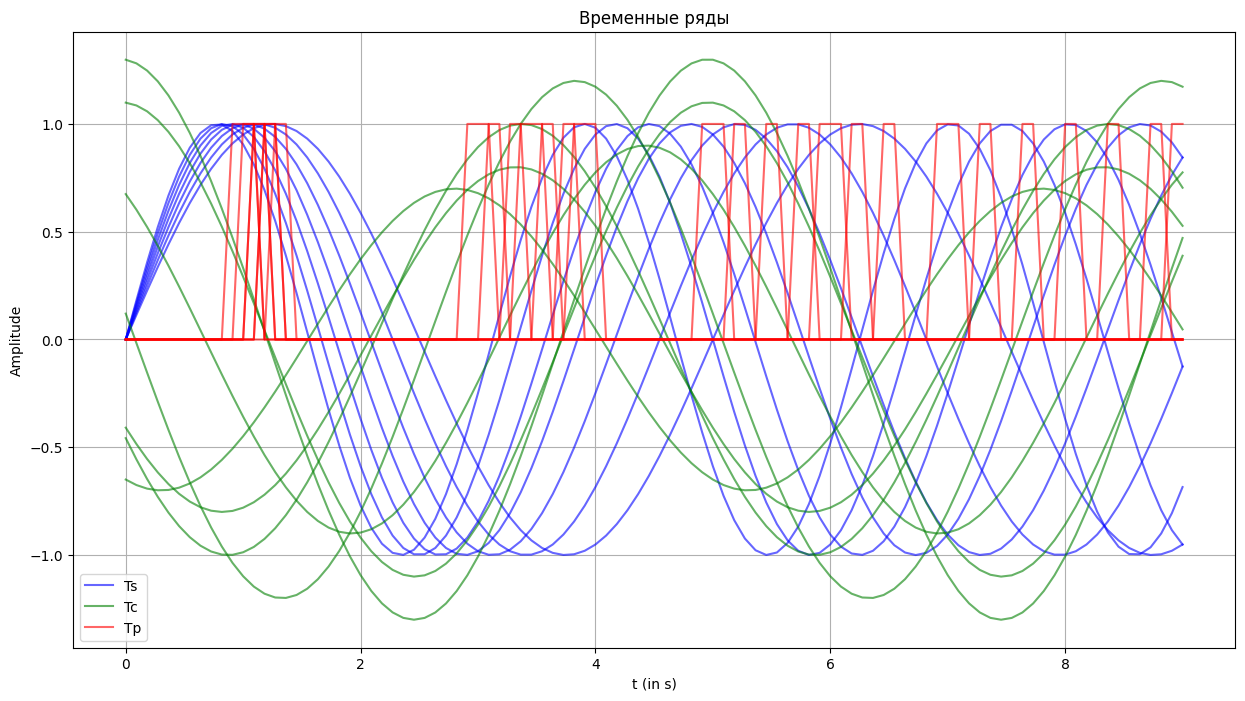

In [4]:
# индекс и отсчет времени в секундах
time_index = np.linspace(0, 9, 100)

tseries_list = {'Time': time_index}
d = np.random.random(size=10)


N = 7 #количество образцов в каждом типе сигналов


# гармонические колебания
f0 = 0.2

for i in range(N):
    # Добавляем небольшую случайную фазу и амплитуду для разнообразия
    phase = d[i % len(d)] * np.pi
    amp = 1 + 0.1 * (i - 3)
    tseries_list["Tc"+str(i)] = amp * np.cos(2 * np.pi * f0 * time_index + phase)

# модифицированный синус
for i in range(N):
    # Модифицированный синус: синус с измененной частотой
    freq_mod = f0 * (1 + 0.1 * i)
    tseries_list["Ts"+str(i)] = np.sin(2 * np.pi * freq_mod * time_index)

# пульс сигнал
for i in range(N):
    # Пульс-сигнал: последовательность импульсов
    period = 2.0 + 0.1 * i # меняем период
    signal = np.zeros_like(time_index)
    for t_idx, t_val in enumerate(time_index):
        # Создаем импульсы каждые period секунд
        if abs((t_val % period) - period/2) < 0.1: # узкий импульс
            signal[t_idx] = 1.0
    tseries_list["Tp"+str(i)] = signal


# отрисовка всех сигналов
plt.figure(figsize=(15, 8))

# Ts - синие
for i in range(N):
    plt.plot(time_index, tseries_list["Ts"+str(i)], 'b-', alpha=0.6, label='Ts' if i == 0 else "")

# Tc - зеленые
for i in range(N):
    plt.plot(time_index, tseries_list["Tc"+str(i)], 'g-', alpha=0.6, label='Tc' if i == 0 else "")

# Tp - красные
for i in range(N):
    plt.plot(time_index, tseries_list["Tp"+str(i)], 'r-', alpha=0.6, label='Tp' if i == 0 else "")

plt.title(r'Временные ряды')
plt.xlabel(r't (in s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

# Понимание Динамическое искажение (деформация) времени (Dynamic time warping, DTW)

DTW - это метод, который вычисляет оптимальное соответствие между двумя заданными последовательностями (например, временными рядами) с определенными ограничениями и правилами:

1. Каждый индекс из первой последовательности должен быть сопоставлен с одним или несколькими индексами из другой последовательности и наоборот

1. Первый индекс из первой последовательности должен совпадать с первым индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Последний индекс из первой последовательности должен совпадать с последним индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Отображение индексов из первой последовательности на индексы из другой последовательности должно монотонно возрастать, и наоборот, т. е. если j>i являются индексами из первой последовательности, то в другой последовательности не должно быть двух индексов l> k, так что индекс i совпадает с индексом l, а индекс j - с индексом k, и наоборот.

Рассмотрим два временных ряда $x$ и $x^{\prime}$ соответствующей длины n и m. Предполагается, что все элементы этих рядов лежат в одном и том же  p - одномерном пространство и точные временные метки, в которые происходят наблюдения, не принимаются во внимание, важен только их порядок.

Более формально задача оптимизации записывается в виде:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left( \sum_{(i, j) \in \pi} d(x_i, x^\prime_j)^q \right)^{\frac{1}{q}}
$


Здесь путь выравнивания $\pi$  длины K  представляет собой последовательность K  пары индексов $((i_0,j_0),..,(i_{K-1},j_{K-1}))$
 и  $A(x,x^{\prime})$
 представляет собой набор всех допустимых путей. Чтобы считаться допустимым, путь должен удовлетворять следующим условиям:

Начало (соответственно, конец) временных рядов сопоставляются друг с другом:

$
\pi_0 = (0, 0)
$

$
\pi_{K-1} = (n - 1, m - 1)
$

Последовательность монотонно увеличивается в обоих $i$ и $j$  и все индексы временных рядов должны отображаться хотя бы один раз, что может быть записано как:

$
i_{k-1} \leq i_k \leq i_{k-1} + 1
$

$
j_{k-1} \leq j_k \leq j_{k-1} + 1
$


Другим способом представления  DTW является использование двоичной матрицы, ненулевые элементы которой соответствуют совпадениям между элементами временного ряда. Это представление связано с представлением последовательности индексов, использованным выше:

$
\begin{equation}
(A_\pi)_{i,j} = \left\{ \begin{array}{rl} 1 & \text{ if } (i, j) \in \pi \\
                                      0 & \text{ otherwise}
                        \end{array} \right. \,\,\,\,\,\,\, .
\end{equation}
$

Тогда  DTW может быть выражено через скалярные произведения следующим образом:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left\langle A_\pi,  D_q({x}, {x}^\prime) \right\rangle^{\frac{1}{q}}
 $

Решение поставленной задачи оптимизации может быть найдено с помощью динамического программирования.
Обозначим:

$
R_{i,j} = DTW_q({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})^q
$

где ${x}_{\rightarrow i}$ - обозначает наблюдение ряда до отметки i

Тогда получаем реккурентную формулу:

$
\begin{aligned}
R_{i,j}
    &= \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
        \sum_{(k, l) \in \pi} d(x_k, x^\prime_l)^q \\
    &\stackrel{*}{=} d(x_i, x^\prime_j)^q +
        \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
            \sum_{(k, l) \in \pi[:-1]} d(x_k, x^\prime_l)^q \\
    &\stackrel{**}{=} d(x_i, x^\prime_j)^q +
        \min ({\color{Blue}R_{i-1, j}}, {\color{Red}R_{i, j-1}}, {\color{ForestGreen}R_{i-1, j-1}})
\end{aligned}
$

\* - потому, что последний элемент на допустимом пути должен соответствовать последним элементам ряда.

** - результат условий смежности допустимых путей.

In [5]:
def distance_matrix(x, y, q) -> np.array:
    """
    Функция  рассчета  матрицы  расстояний между точками двух рядов
    """
    mdist = np.zeros((len(y), len(x)))
    # TODO: Напишите вложенные циклы для заполнения матрицы mdist расстояниями: |x[j] - y[i]|**q
    for i in range(len(y)):
        for j in range(len(x)):
            mdist[i, j] = abs(x[j] - y[i]) ** q

    return mdist

In [6]:
def DTW(x, x_s, q=1, isDTW=True):
    '''
        x: первый ряд
        x_s : второй ряд
        q : степень для вычисления базового расстояния
    '''
    N = len(x) # Считаем, что ряды равной длины. Но это не всегда так, перепишите функцию для
               # вычисления расстояния между рядами, длины которых не равны

    # Строим матрицу согласно реккурентной формуле, полученной выше. Матрица в нашем случае будет размерности

    dist = distance_matrix(x,x_s,q=2)

    R = [[0] * (N+1) for i in range(N+1)]

    # Исправление границ: нужно заполнить до N+1, чтобы захватить весь крайний ряд/столбец
    for i in range(1, N+1):
        R[i][0] = dist[i-1,0] + R[i-1][0] # dist индексируется с 0, R с 1 (из-за padding)
        R[0][i] = dist[0,i-1] + R[0][i-1]

    k = 0
    if isDTW:
        k = 1

    # начинаем расчет по реккурентной формуле

    for i in range(1, N+1):
        for j in range(1, N+1):
            # TODO: Реализуйте шаг вычисления реккурентной формулы расчета матрицы R для DTW
            # R[i][j] = dist[i-1][j-1] + min(R[i-1][j], R[i][j-1], R[i-1][j-1])
            R[i][j] = dist[i-1, j-1] + min(R[i-1][j], R[i][j-1], R[i-1][j-1])

    # ищем минимальный путь. Начинаем от нижнего правого угла.
    pth = []   # лист с кортежами индексов пути
    i = N
    j = N
    while i >= 0 and j >= 0:
        pth.append((i,j))
        if i == 0 and j == 0:
            break

        val_diag = R[i-1][j-1] if i > 0 and j > 0 else float('inf')
        val_up = R[i-1][j] if i > 0 else float('inf')
        val_left = R[i][j-1] if j > 0 else float('inf')

        min_val = min(val_diag, val_up, val_left)

        if min_val == val_left:
            I = i
            J = j - 1
        elif min_val == val_up:
            I = i - 1
            J = j
        else:
            I = i - 1
            J = j - 1

        i = I
        j = J


    #print("\nПуть:")
    #print(pth)

    #Считаем расстояние между двумя рядами
    s = 0
    for l in pth:
        # Важно: суммируем значения из матрицы накопленных стоимостей R вдоль пути
        s += R[l[0]][l[1]]

    # Нормализация (среднее значение вдоль пути)
    if len(pth) > 0:
        s = s / len(pth)
    else:
        s = 0

    return s, pth, R

In [7]:
# Посчитаем DTW для двух временных рядов

#для простоты выделяем ряды, которые будем сравнивать
x = np.abs(tseries_list.get("Ts1", np.zeros(100))) # Если tseries_list не заполнен
x_s = np.abs(tseries_list.get("Ts6", np.zeros(100)))
x_p = np.abs(tseries_list.get("Tp2", np.zeros(100)))

s1 = DTW(x, x_s, q=2)
s2 = DTW(x, x_p, q=2)

print (f"DTW\nTs1 и Ts6 = {s1[0]}     Ts1 и Tp2 = {s2[0]}")

s11 = DTW(x, x_s, q=2, isDTW=False)
s21 = DTW(x, x_p, q=2, isDTW=False)

print (f"Dec\nTs1 и Ts6 = {s11[0]}     Ts1 и Tp2 = {s21[0]}")

DTW
Ts1 и Ts6 = 2.003676995553895     Ts1 и Tp2 = 3.163454392544411
Dec
Ts1 и Ts6 = 2.003676995553895     Ts1 и Tp2 = 3.163454392544411


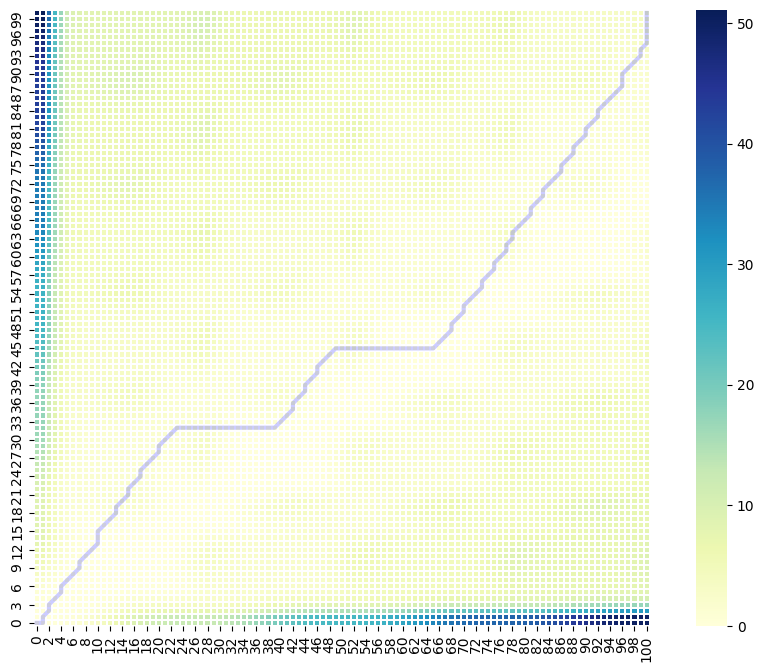

In [8]:
import seaborn as sbn
# Отрисуем матрицы весов расстояний Ts1 и Ts3

cost_matrix = s1[2]
warp_path = s1[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

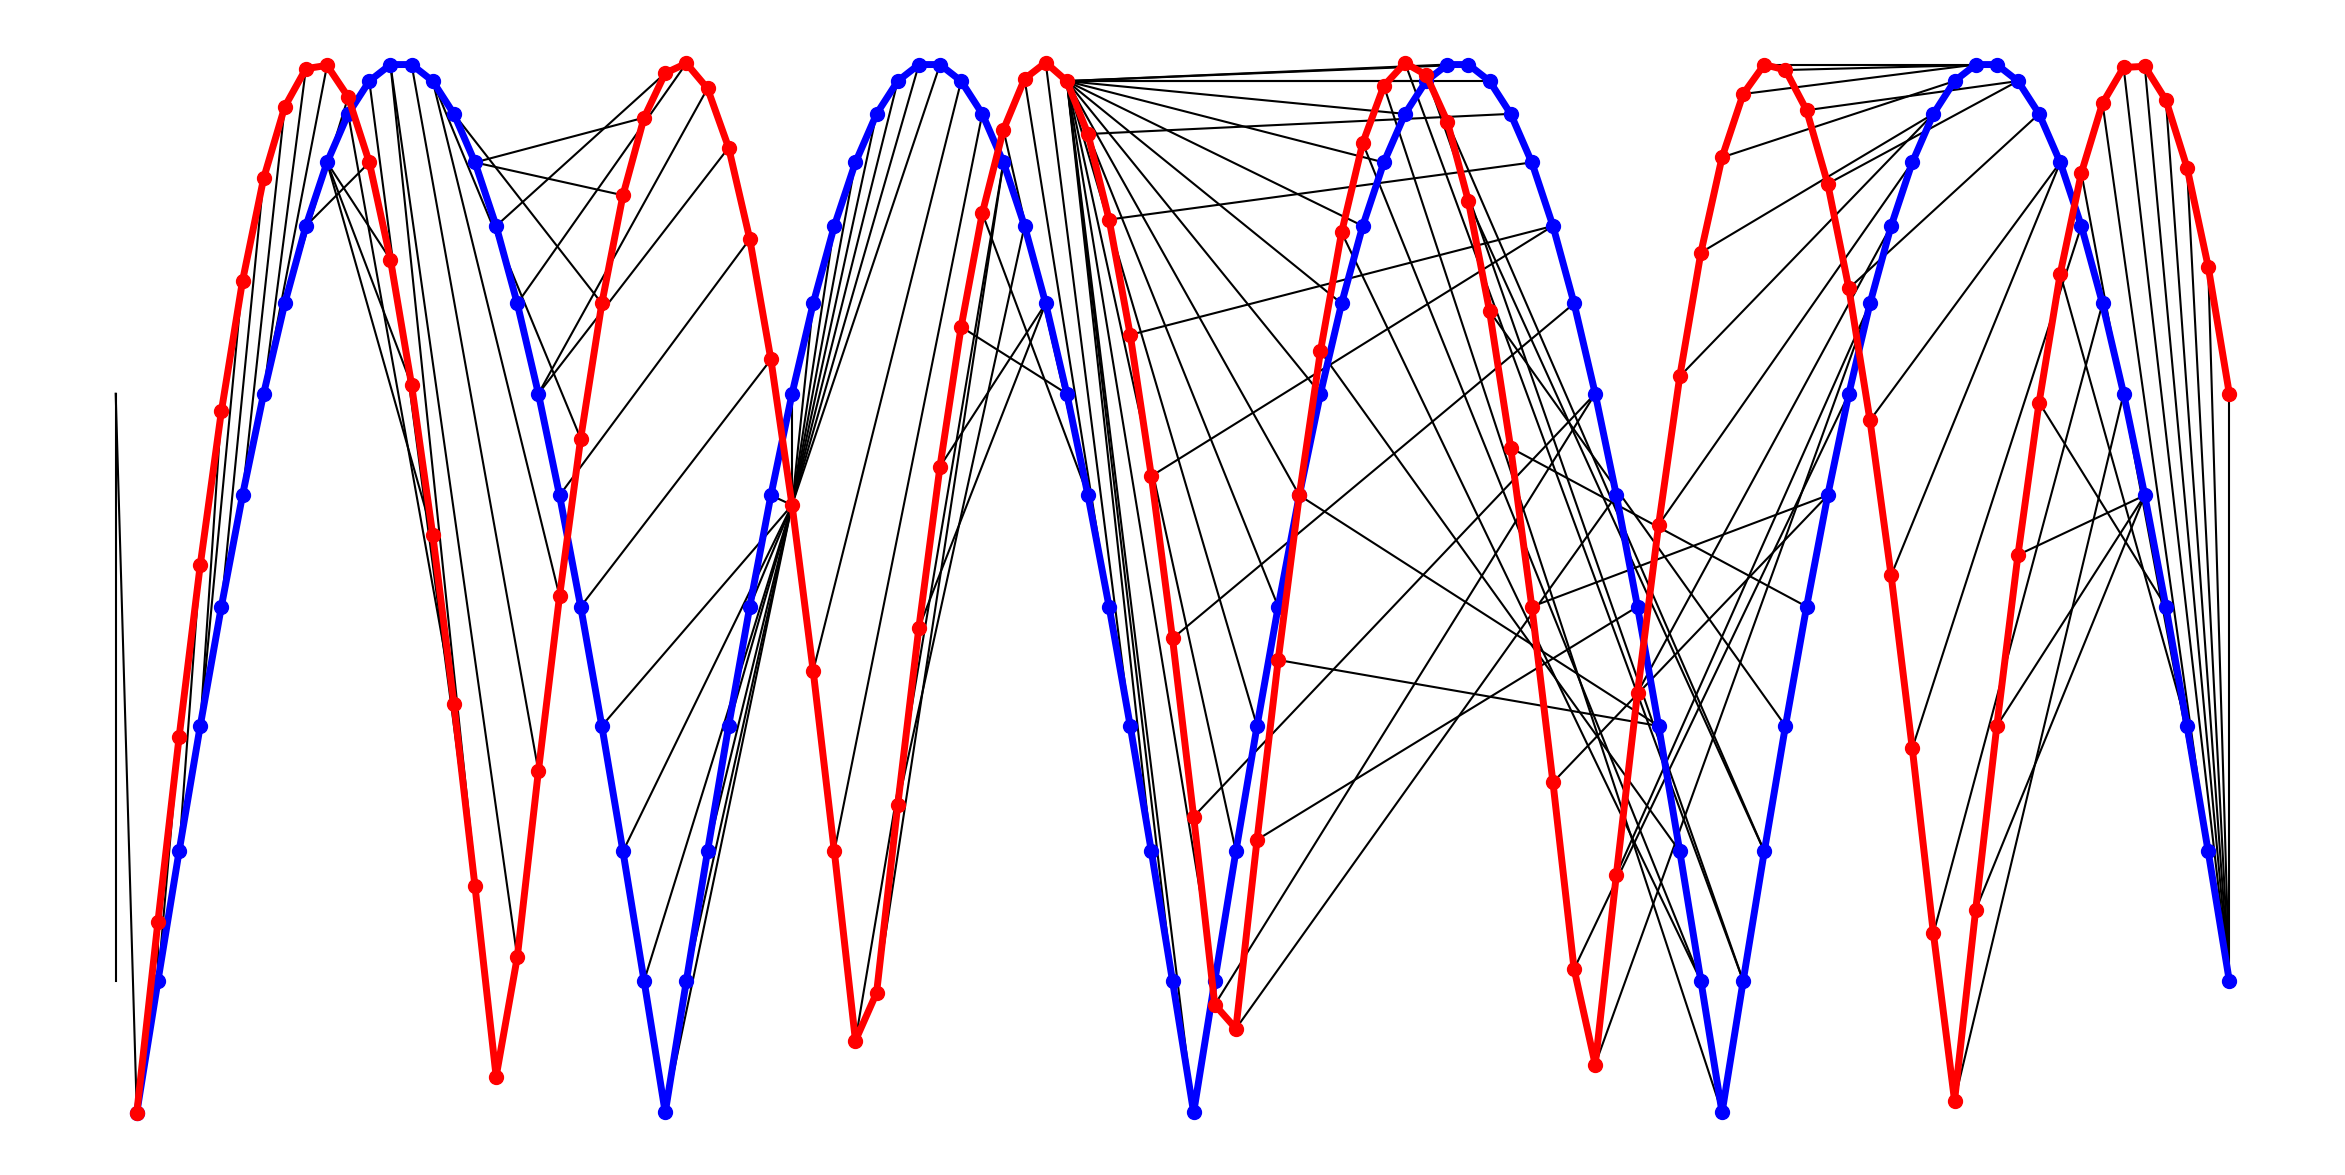

In [9]:
fig, ax = plt.subplots(figsize=(30, 15))


warp_path = s1[1]
x1 = x
x2 = x_s

# Remove the border and axes ticks
fig.patch.set_visible(True)
ax.axis('off')

for [map_x, map_y] in warp_path:
    ax.set_facecolor('white')
    ax.plot([map_x-1, map_y-1], [x1[map_x-1], x2[map_y-1]], '-k')

ax.plot(x1, color='blue', marker='o', markersize=10, linewidth=5)
ax.plot(x2, color='red', marker='o', markersize=10, linewidth=5)
ax.tick_params(axis="both", which="major", labelsize=18)

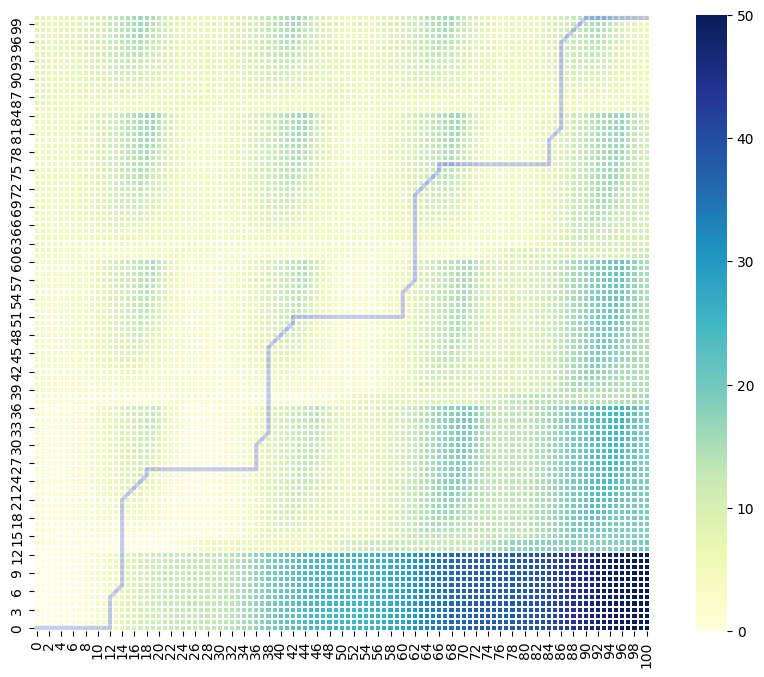

In [10]:
# Отрисуем матрицы весов расстояний Ts1 и Tp1

cost_matrix = s2[2]
warp_path = s2[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

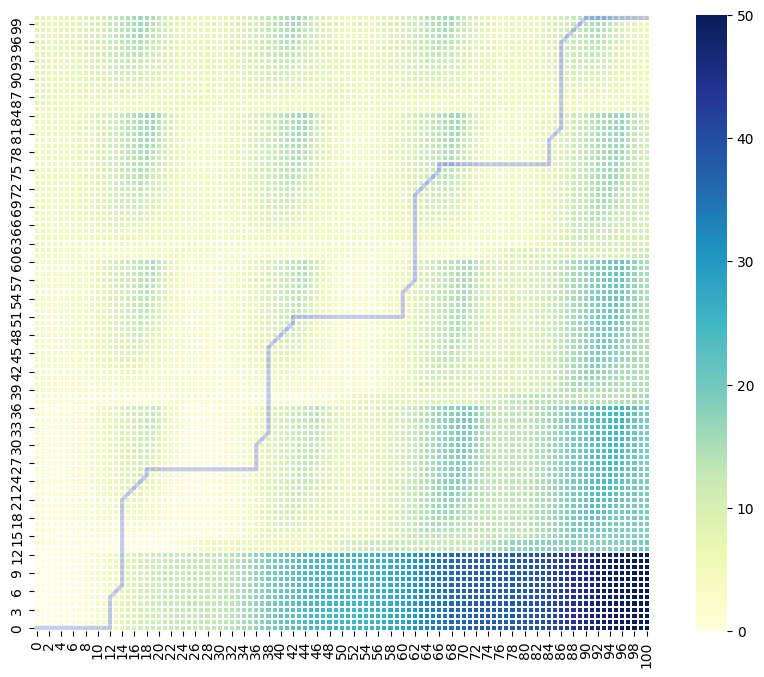

In [11]:
# Отрисуем матрицы весов расстояний Ts1 и Tp1 без DTW

cost_matrix = s21[2]
warp_path = s21[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

А теперь попробуем вычислить тоже самое, но с помощью встроенных функций Python

In [16]:
from dtaidistance import dtw

x = np.abs(tseries_list["Ts1"])
x_s = np.abs(tseries_list["Ts6"])

# Вычислите расстояние и пути с помощью встроенной функции dtw.warping_paths из библиотеки dtaidistance
distance, paths = dtw.warping_paths(x, x_s)
print(distance)
print(paths)

2.0178047655604776
[[0.                inf        inf ...        inf        inf        inf]
 [       inf 0.         0.18176748 ... 7.06869398 7.11445716 7.14731456]
 [       inf 0.12533323 0.05643424 ... 5.97473782 6.013345   6.0392912 ]
 ...
 [       inf 7.06558171 5.49093328 ... 1.91863748 1.91666204 1.88913853]
 [       inf 7.06995697 5.49134108 ... 2.01069327 1.99594437 1.9387666 ]
 [       inf 7.07106781 5.49163106 ... 2.12578649 2.10870101 2.01780477]]


In [33]:
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
import random
import numpy as np
xw = np.arange(0, 20, .5)
s1 = x
s2 = x_s
random.seed(1)
for idx in range(len(s2)):
    if random.random() < 0.05:
        s2[idx] += (random.random() - 0.5) / 2
d, paths = dtw.warping_paths(s1, s2, window=25, psi=2)
best_path = dtw.best_path(paths)
dtwvis.plot_warpingpaths(s1, s2, paths, best_path)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [22]:
x = np.abs(tseries_list["Ts1"])
x_p = np.abs(tseries_list["Tp2"])


distance, paths = dtw.warping_paths(x, x_p)
print(distance)
print(paths)

2.5657644092323153
[[0.                inf        inf ...        inf        inf        inf]
 [       inf 0.         0.         ... 2.82842712 2.82842712 2.82842712]
 [       inf 0.12533323 0.12533323 ... 2.71027532 2.71317171 2.71606502]
 ...
 [       inf 7.06558171 7.06558171 ... 2.77554762 2.79985362 2.82395042]
 [       inf 7.06995697 7.06995697 ... 2.63950267 2.65119237 2.66283076]
 [       inf 7.07106781 7.07106781 ... 2.55963477 2.56270142 2.56576441]]


TypeError: list indices must be integers or slices, not tuple

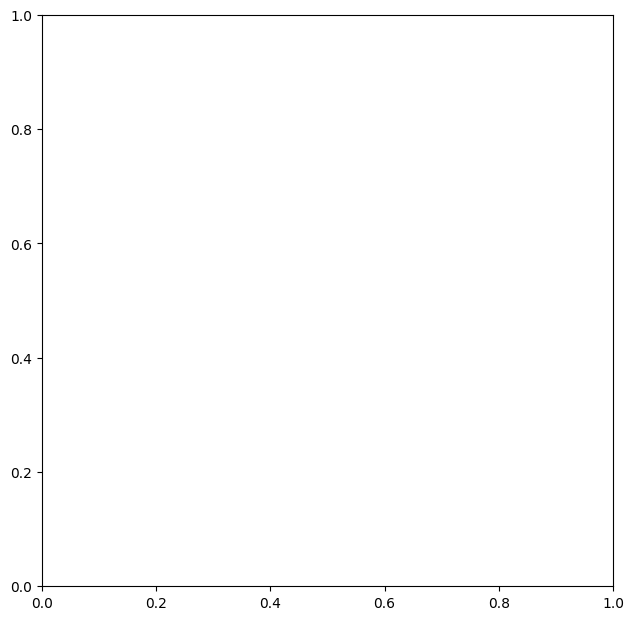

In [27]:
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
import random
import numpy as np
xw = np.arange(0, 20, .5)
s1 = x
s2 = x_p
random.seed(1)
for idx in range(len(s2)):
    if random.random() < 0.05:
        s2[idx] += (random.random() - 0.5) / 2
d, paths = dtw.warping_paths(s1, s2, window=25, psi=2)
best_path = dtw.best_path(paths)
dtwvis.plot_warpingpaths(s1, s2, paths, best_path)

In [29]:
# переделываем датасет так, чтобы с ним можно было бы работать

X = []  # значения
Y = []  # целевая переменная

for v in tseries_list:
    if v != 'Time':
        X.append(tseries_list[v])
        c = v[:-1]
        if c == "Ts":
            Y.append(0)
        elif c == "Tc":
            Y.append(1)
        else:
            Y.append(2)

arr = np.arange(len(Y))
np.random.shuffle(arr)

# print(Y) # Раскомментируйте, если нужно посмотреть на исходный порядок классов

X_train = []
X_test = []
y_train = []
y_test = []

# TODO: Заполните списки X_train, y_train, X_test, y_test
# Для этого отделите от перемешанных индексов arr последние 5 элементов под тест,
# а остальные возьмите для трейна.

# Индексы для теста: последние 5 элементов перемешанного массива
test_indices = arr[-5:]
# Индексы для трейна: все остальные элементы
train_indices = arr[:-5]

# Заполняем тестовые выборки
for idx in test_indices:
    X_test.append(np.array(x[idx])) # Преобразуем список в numpy array
    y_test.append(Y[idx])

# Заполняем обучающие выборки
for idx in train_indices:
    X_train.append(np.array(x[idx])) # Преобразуем список в numpy array
    y_train.append(Y[idx])

# Преобразуем списки в numpy массивы
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (16, 100)
Размер тестовой выборки: (5, 100)


In [30]:
from pyts.classification import KNeighborsClassifier

# Инициализируем классификатор с метрикой DTW
clf = KNeighborsClassifier(metric='dtw')

# Обучаем модель
clf.fit(X_train, y_train)

# Проверяем точность и делаем предсказания (раскомментируйте для проверки)
print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Accuracy 1.0
Вектор вероятности принадлежности к классам [[1. 0. 0.]]
Истинный класс для предсказаний 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

In [31]:
import numpy as np
from pyts.classification import TimeSeriesForest
import matplotlib.pyplot as plt

# Инициализируем классификатор TimeSeriesForest с фиксированным random_state для воспроизводимости
clf = TimeSeriesForest(random_state=43)

# Обучаем модель
clf.fit(X_train, y_train)

# Проверяем точность и делаем предсказания (раскомментируйте для проверки)
print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 0.8
Вектор вероятности принадлежности к классам [[0.464 0.384 0.152]]
Истинный класс для предсказаний 0


In [32]:
# TODO: Обучите модель KNN со стандартной (евклидовой) метрикой расстояния
# В домашнем задании требовалось сделать 3 модели на выбор.

from pyts.classification import KNeighborsClassifier

# Инициализируем классификатор с евклидовой метрикой
clf_eucl = KNeighborsClassifier(metric='euclidean')

# Обучаем модель
clf_eucl.fit(X_train, y_train)

# Проверяем точность и делаем предсказания (раскомментируйте для проверки)
print(f"Accuracy {clf_eucl.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf_eucl.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 0.8
Вектор вероятности принадлежности к классам [[1. 0. 0.]]
Истинный класс для предсказаний 0
